# Diabetes Prediction Using Machine Learning (Healthcare Analytics)
## Prepared By: Minal Choudhary

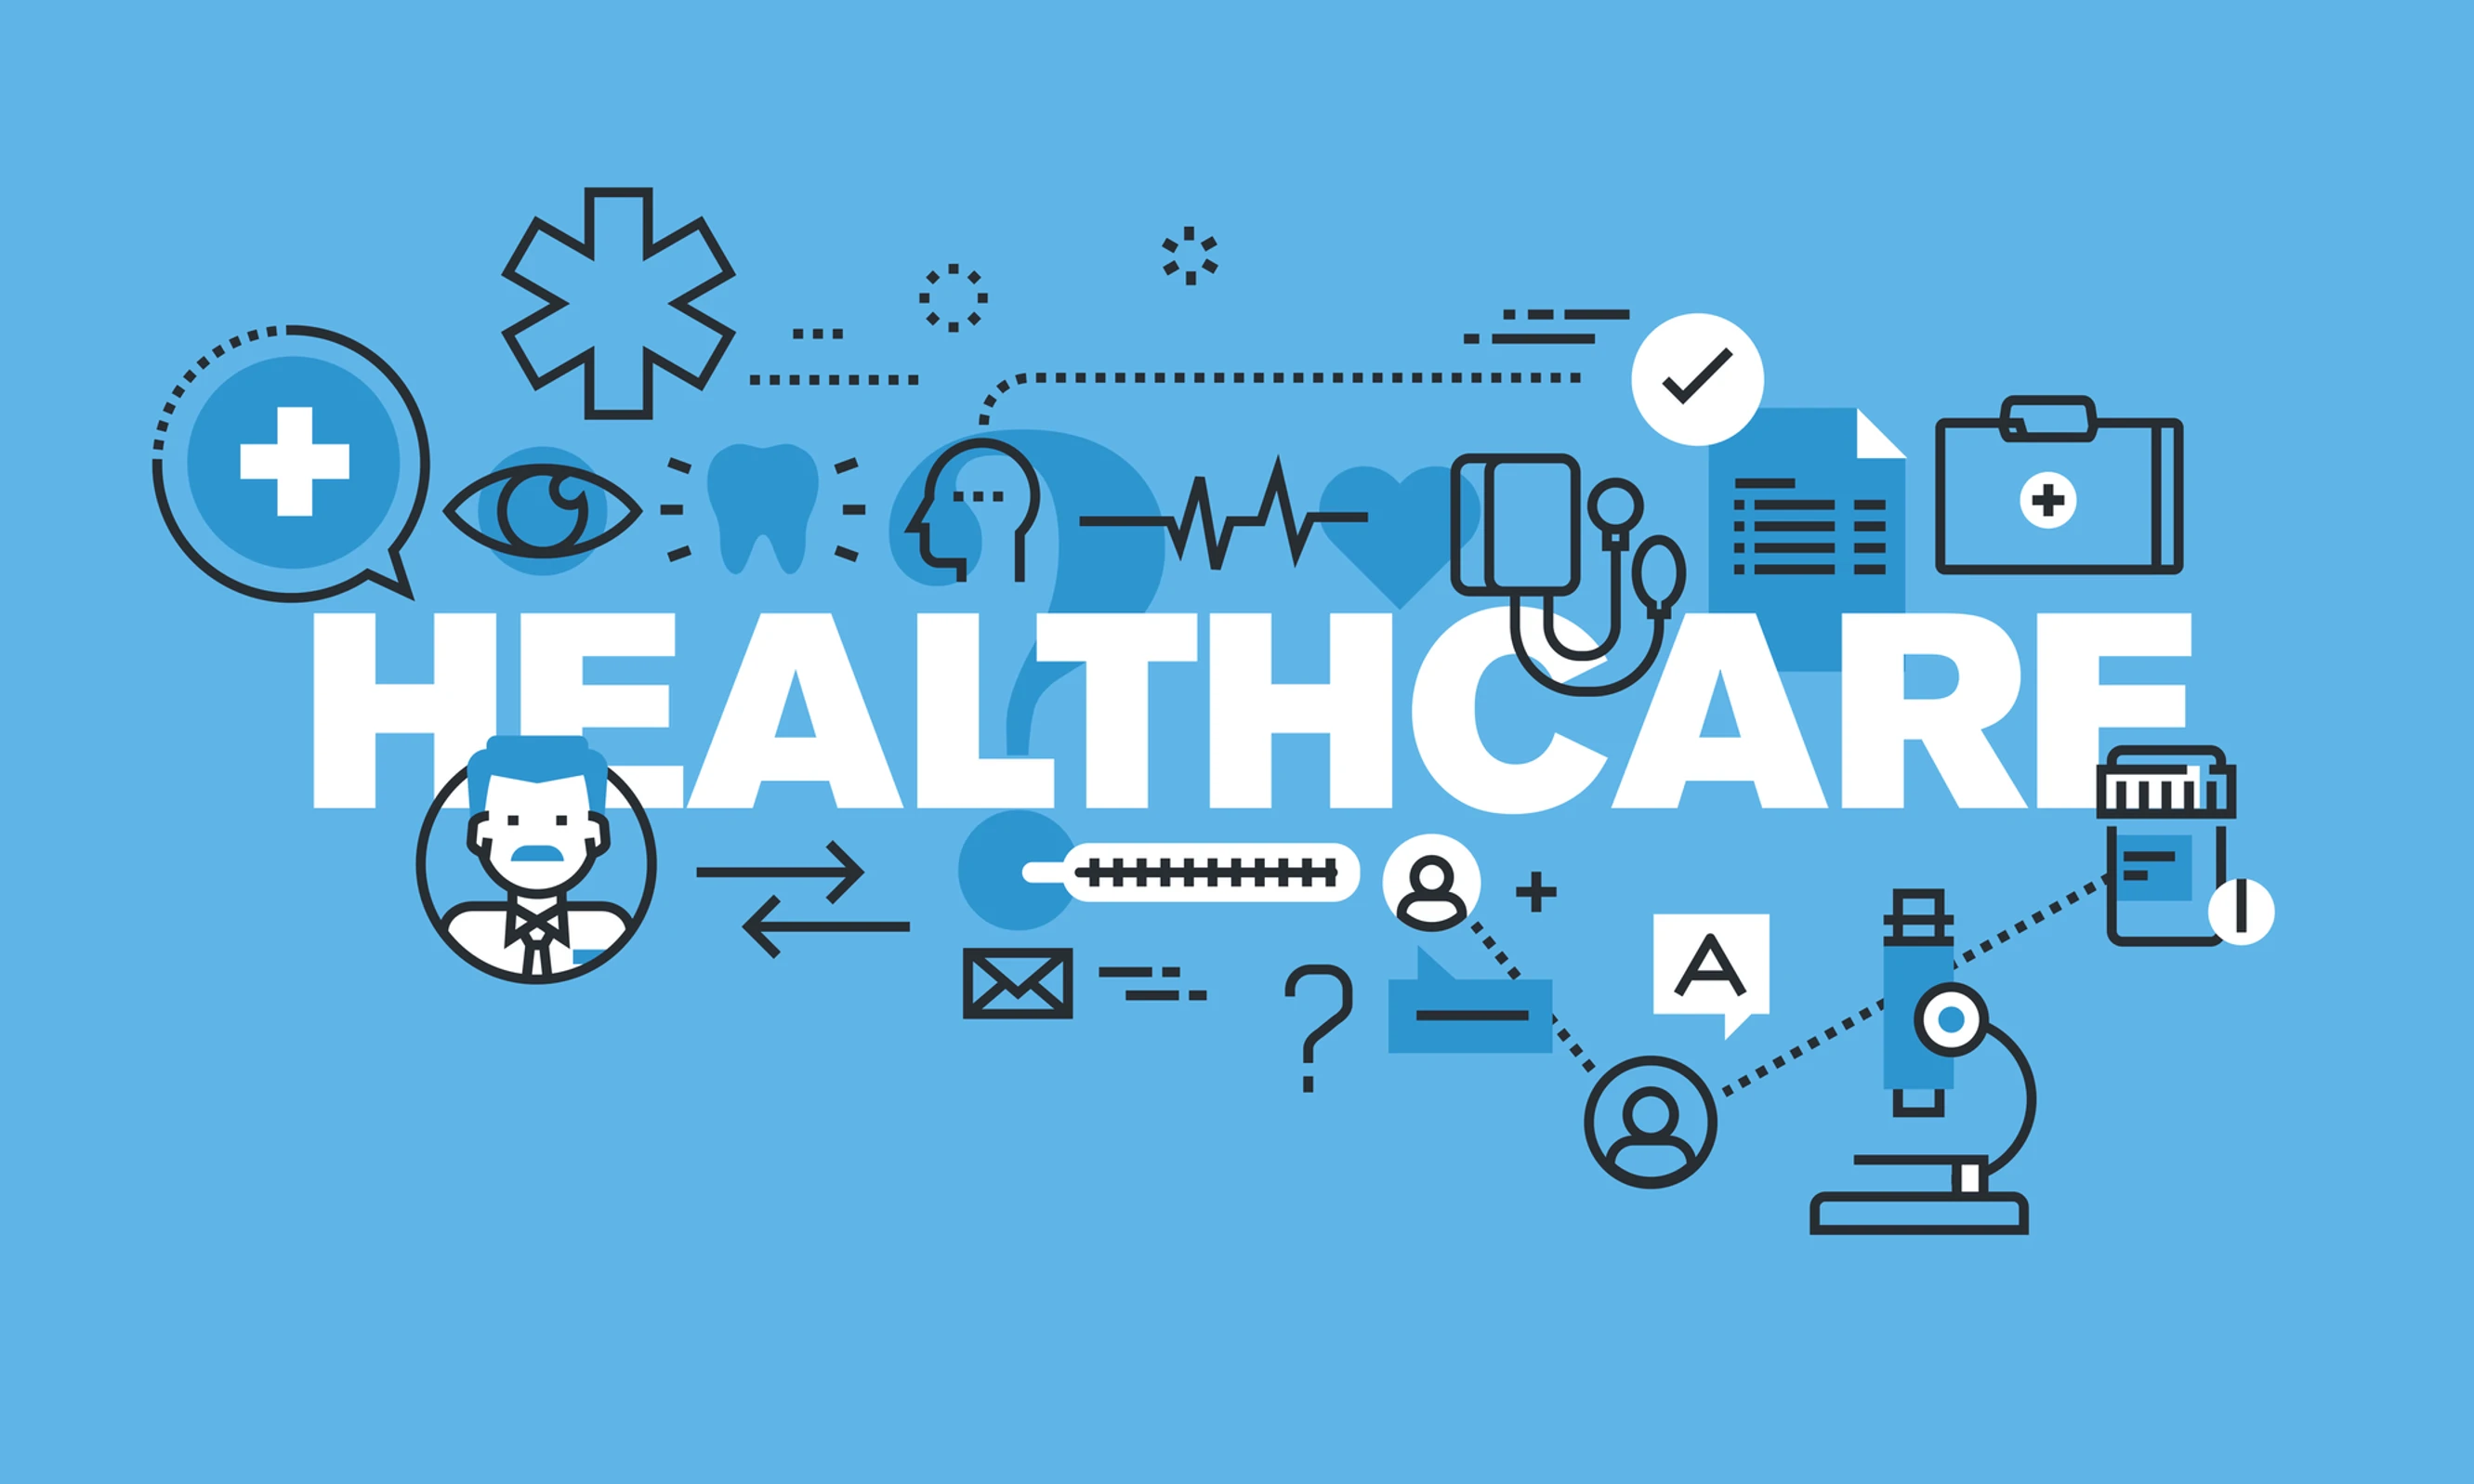


This project applies Machine Learning techniques to predict the likelihood of diabetes in 
patients using key medical features such as Glucose Level, BMI, Insulin, Blood Pressure, 
and Age. 
The analysis is based on the widely used Pima Indian Diabetes Dataset, which contains 
diagnostic data for female patients of Pima Indian heritage. The target variable Outcome 
represents whether a patient has diabetes (1) or not (0). 

### Objective:

The primary objective of this project is to develop a predictive model that can accurately 
identify whether an individual is at risk of developing diabetes. 
By analyzing medical indicators and using machine learning algorithms, the project aims to: 
- Support early detection of diabetes 
- Help healthcare professionals identify high-risk individuals 
- Build a reliable model based on interpretable features 
- Demonstrate end-to-end ML workflow using Python 

### Dataset Overview:

The dataset contains the following medical attributes: 
- Pregnancies 
- Glucose Level 
- Blood Pressure 
- Skin Thickness 
- Insulin Level 
- BMI (Body Mass Index) 
- Diabetes Pedigree Function 
- Age 
- Outcome (1 = Diabetic, 0 = Non-Diabetic) 
Each row represents one patient. Several features contain zeros, which in medical context 
represent missing values rather than actual measurements — this is addressed during 
cleaning.

# Importing Libraries and Loading the Dataset 

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import pickle

In [8]:
df = pd.read_csv("Diabetes_Prediction_Project_Dataset.csv")

In [9]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Understanding the Dataset 
#### In this step, we explore the dataset to understand its: 
- Size 
- Structure 
- Column types 
- Missing values 
- Statistical summary 

This helps identify data quality issues and guides preprocessing decisions.

In [10]:
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())

Dataset Shape: (768, 9)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [11]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [12]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Exploratory Data Analysis (EDA) 
EDA is performed to visually understand the patterns, correlations, and distribution of 
features. 

### 1. Outcome Distribution 
A count plot is used to observe the class balance between diabetic and non-diabetic 
patients. This is essential because imbalanced data can affect model performance.

### 2. Correlation Heatmap 
A heatmap is plotted to show the relationships between numerical features. 
A strong positive correlation between Glucose and Outcome indicates glucose level is a major determinant of diabetes. 

### 3. Feature Distributions 
Histograms with KDE curves help visualize how key features such as Glucose, BMI, Age, 
and Blood Pressure are distributed in the population. 

These insights help identify outliers and understand typical patient ranges.

C:\Users\minal choudhary\AppData\Local\Temp\ipykernel_23912\4058938534.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='coolwarm')


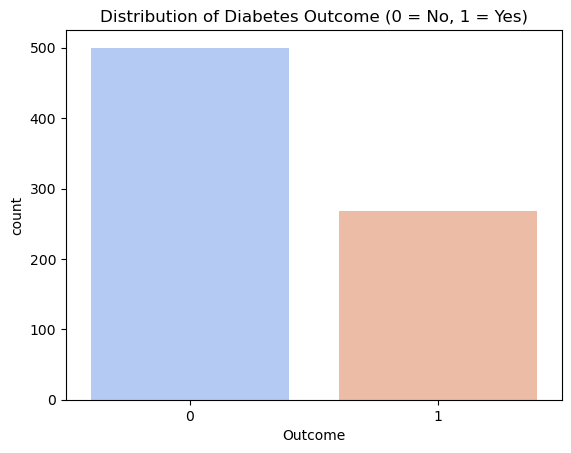

In [13]:
sns.countplot(x='Outcome', data=df, palette='coolwarm')
plt.title("Distribution of Diabetes Outcome (0 = No, 1 = Yes)")
plt.show()

## Explanation:
- This bar chart shows the number of diabetic (1) and non-diabetic (0) patients.
- Typically, non-diabetic cases are higher, which is important for class balance consideration.

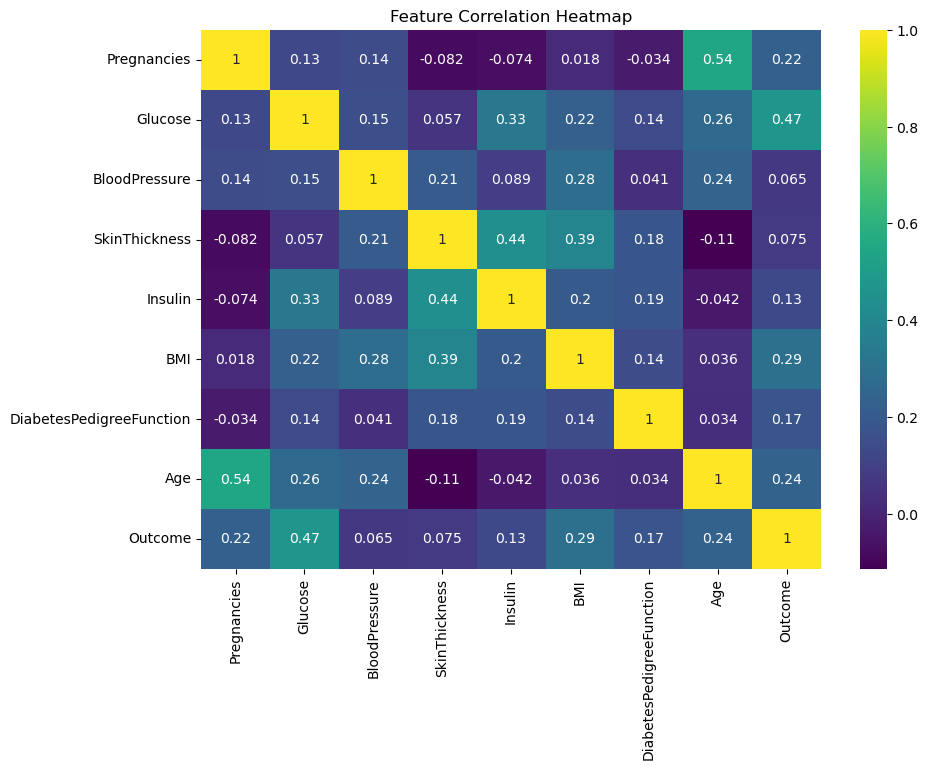

In [14]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, cmap='viridis')
plt.title("Feature Correlation Heatmap")
plt.show()

## Explanation:
- This heatmap reveals how features are related to each other.
- Glucose has a strong positive correlation with the Outcome variable, meaning it is a significant indicator of diabetes.

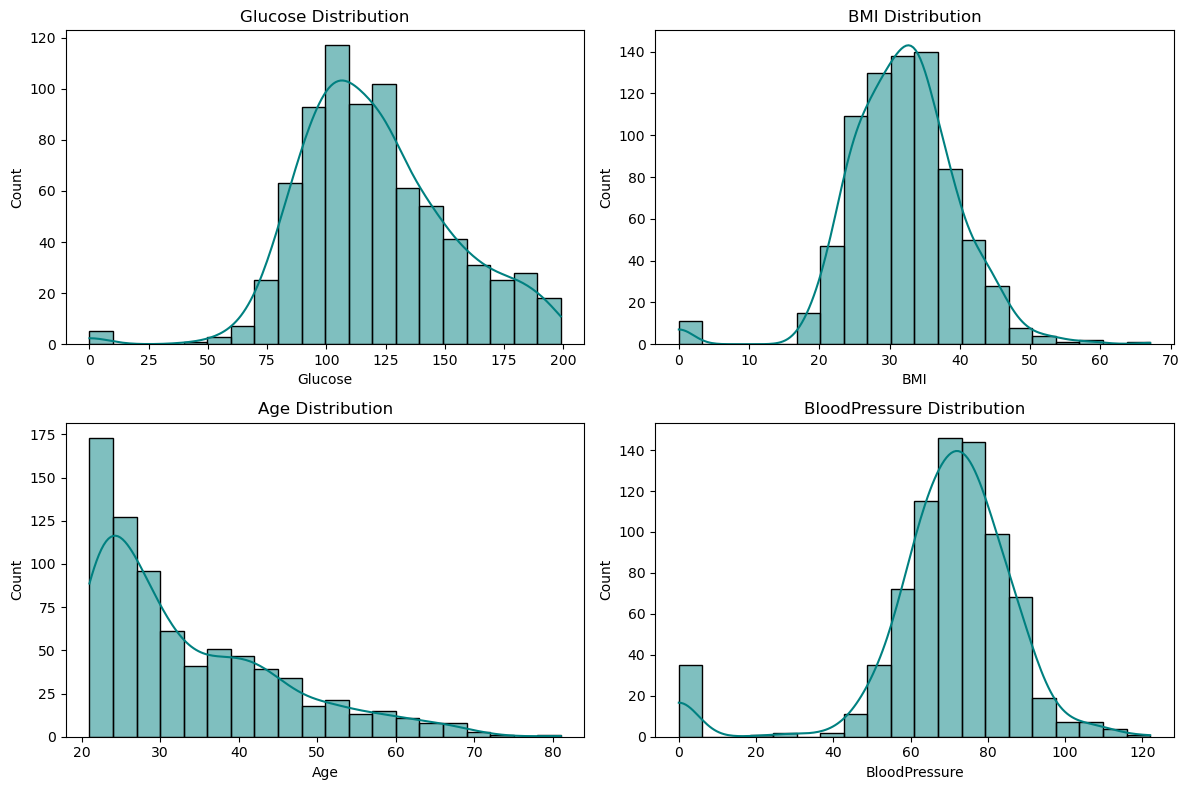

In [15]:
features = ['Glucose', 'BMI', 'Age', 'BloodPressure']
plt.figure(figsize=(12,8))
for i, feature in enumerate(features, 1):
    plt.subplot(2,2,i)
    sns.histplot(df[feature], kde=True, bins=20, color='teal')
    plt.title(f"{feature} Distribution")
plt.tight_layout()
plt.show()

## Explanation:
### Each histogram shows how a health metric is distributed:
- Glucose: Most values are around 100–150, higher values often indicate diabetes.
- BMI: Higher BMI (>30) increases diabetes risk.
- Age: Middle-aged and older people tend to have higher risk.
- BloodPressure: Usually around 70–80 mm Hg for most patients.
## ____________________________________________________________________________

# Data Cleaning and Preprocessing

Some medical features like Glucose, Blood Pressure, and BMI contain zero values, which 
are biologically impossible and represent missing data.

#### Steps performed:

1. Zero values are replaced with NaN for relevant columns 
2. The missing values are imputed using the median of each column 
3. Data is rechecked to ensure no missing values remain 

This ensures clean, reliable input for model training. 

In [16]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

In [17]:
print("Missing Values After Replacing Zeros:\n", df.isnull().sum())

Missing Values After Replacing Zeros:
 Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [18]:
for col in cols_with_zeros:
    df[col].fillna(df[col].median(), inplace=True)

In [19]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## Explanation:
- Zero values are unrealistic for some medical metrics (e.g., Glucose = 0),
- so replacing them with the column median ensures data integrity.
## ____________________________________________________________________________

# Feature Scaling and Train–Test Split

#### Before training the model: 
    
- The dataset is split into 80% training and 20% testing 
- Features are standardized using StandardScaler 
- Scaling ensures the model performs efficiently 
- Especially necessary for algorithms like Logistic Regression

This prepares the data for model training.

In [20]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training and testing data prepared successfully!")

Training and testing data prepared successfully!


# Model Building (Logistic Regression & Random Forest) 

### Two machine learning models are built: 

#### 1. Logistic Regression 
A linear model that predicts the probability of diabetes. 
Useful for understanding which features strongly influence the prediction.

#### 2. Random Forest Classifier 
An ensemble model that handles non-linear relationships well. 
Often provides higher accuracy and better generalization. 

Both models are trained on the prepared dataset and used to generate predictions.

In [22]:
lr = LogisticRegression(max_iter=1000, solver='liblinear')
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("✅ Models trained successfully!")

✅ Models trained successfully!


# Model Evaluation 

#### Models are evaluated using: 
- Accuracy 
- Precision 
- Recall 
- F1-Score 
- Confusion Matrix 
- ROC-AUC Score

In [23]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)

y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [24]:
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

=== Logistic Regression ===
Accuracy: 0.6948051948051948
ROC-AUC: 0.8127777777777777

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.80      0.77       100
           1       0.57      0.50      0.53        54

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.65       154
weighted avg       0.69      0.69      0.69       154


=== Random Forest ===
Accuracy: 0.7792207792207793
ROC-AUC: 0.8191666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



##  Explanation:
- Accuracy and F1-scores show how well the models perform.
- Random Forest usually performs better due to its ensemble nature, while Logistic Regression gives interpretable results.
## ____________________________________________________________________________

# CONFUSION MATRICES

#### Confusion matrices show: 
- True Positives 
- True Negatives 
- False Positives 
- False Negatives 

These visuals help understand where each model performs well or struggles.

Text(0.5, 1.0, 'Logistic Regression Confusion Matrix')

<Figure size 1200x500 with 0 Axes>

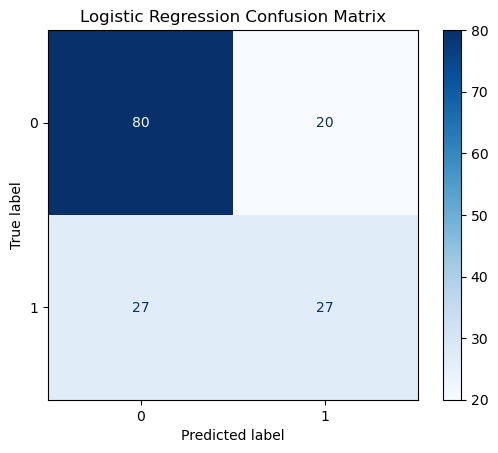

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(12,5))
ConfusionMatrixDisplay.from_estimator(lr, X_test_scaled, y_test, cmap='Blues', values_format='d')
plt.title("Logistic Regression Confusion Matrix")

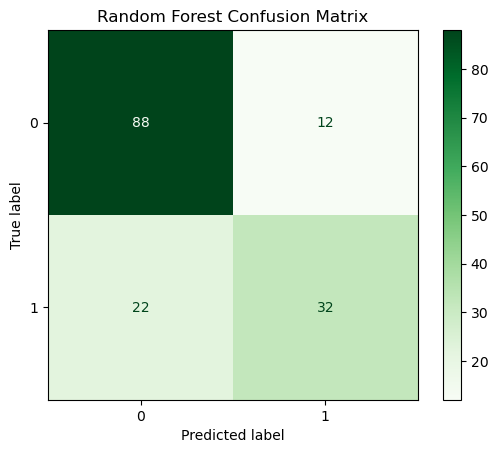

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap='Greens', values_format='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

## Key Findings:

- Logistic Regression provides interpretable coefficients and performs moderately well. 
- Random Forest shows stronger predictive performance with higher accuracy and AUC. 
- Class imbalance slightly affects recall for diabetic cases. 
## ____________________________________________________________________________

# ROC Curve Comparison 

ROC curves compare the tradeoff between True Positive Rate and False Positive Rate for 
both models. 

AUC values closer to 1.0 indicate stronger performance.

Random Forest shows a higher AUC, making it the more powerful classifier in this project.

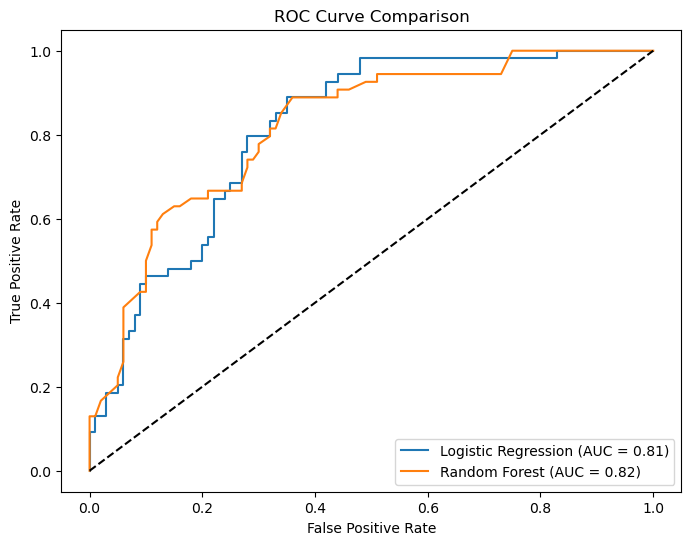

In [27]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Explanation:
- The ROC curve shows how well the model distinguishes between classes.
- The higher the AUC (closer to 1), the better the model performance.
## ____________________________________________________________________________

# Feature Importance (Random Forest) 

A bar plot displays which features most influence the prediction: 
 1. Glucose – most significant predictor 
 2. BMI 
 3. Diabetes Pedigree Function 
 4. Age
    
These medically intuitive results add confidence to the model’s reliability. 

C:\Users\minal choudhary\AppData\Local\Temp\ipykernel_23912\1715017826.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi, palette='viridis')


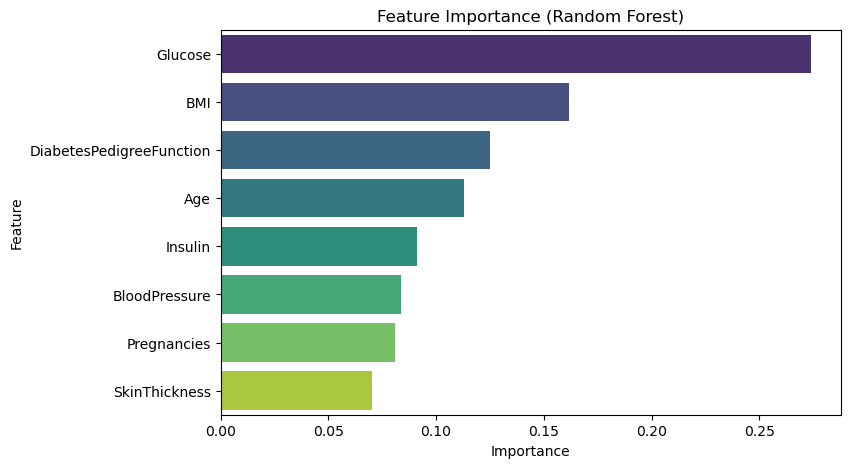

,Feature,Importance
1,Glucose,0.274086
5,BMI,0.161903
6,DiabetesPedigreeFunction,0.125020
7,Age,0.112985
4,Insulin,0.091224
2,BloodPressure,0.083518
0,Pregnancies,0.080795
3,SkinThickness,0.070468


In [28]:
importance = rf.feature_importances_
fi = pd.DataFrame({'Feature': X.columns, 'Importance': importance}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=fi, palette='viridis')
plt.title("Feature Importance (Random Forest)")
plt.show()

fi

## Explanation:
- Glucose is the most important predictor, followed by BMI and Age.
- These factors have a strong influence on diabetes probability.
## ____________________________________________________________________________

# Making a New Prediction 
#### Using a sample patient profile: 
- Features are scaled 
- The Logistic Regression model predicts the probability of diabetes 
- The patient receives a prediction label and probability

This demonstrates how the model can be used in real-world applications.

In [29]:
new_patient = [[2, 120, 70, 25, 80, 32.0, 0.45, 29]]

scaled_input = scaler.transform(new_patient)

prediction = lr.predict(scaled_input)
probability = lr.predict_proba(scaled_input)[0][1]

print("Prediction:", "Diabetic" if prediction[0] == 1 else "Non-Diabetic")
print("Probability of Diabetes:", round(probability, 2))


Prediction: Non-Diabetic
Probability of Diabetes: 0.23


C:\Users\minal choudhary\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Explanation:
- The model returns both the prediction (0 or 1) and the probability score.
- A higher probability (closer to 1) means the patient is more likely to have diabetes.
## ____________________________________________________________________________

# Conclusion 
This project successfully demonstrates how machine learning can assist in medical 
diagnosis by predicting diabetes risk based on key health parameters.

#### Key Takeaways: 
- Glucose, BMI, and Age are the most influential predictors. 
- Random Forest achieved higher accuracy and AUC compared to Logistic Regression. 
- Proper data cleaning, scaling, and preprocessing significantly improved model performance. 

#### Future Enhancements: 
- Implement hyperparameter tuning using GridSearchCV to optimize model performance 
- Add more patient lifestyle data (diet, exercise, stress levels) to improve accuracy 
- Balance the dataset using SMOTE to increase recall for diabetic cases 
- Deploy the model using Streamlit, Flask, or FastAPI for real-time predictions 
- Integrate the project into a web dashboard for hospital use